In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Struktur dan Kualitas Data

1. Load data dan struktur data

In [2]:
df = pd.read_csv("smoking_health_data_final.csv")

print("Tipe data:")
df.info()

print("\nStatistik numerik:")
display(df.describe())

print("\n5 sampel data:")
display(df.sample(5))

Tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             3900 non-null   int64  
 1   sex             3900 non-null   object 
 2   current_smoker  3900 non-null   object 
 3   heart_rate      3900 non-null   int64  
 4   blood_pressure  3900 non-null   object 
 5   cigs_per_day    3886 non-null   float64
 6   chol            3893 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 213.4+ KB

Statistik numerik:


,age,heart_rate,cigs_per_day,chol
count,3900.000000,3900.000000,3886.000000,3893.000000
mean,49.537949,75.688974,9.168554,236.595941
std,8.559275,12.015376,12.037999,44.375365
min,32.000000,44.000000,0.000000,113.000000
25%,42.000000,68.000000,0.000000,206.000000
50%,49.000000,75.000000,0.000000,234.000000
75%,56.000000,82.000000,20.000000,263.000000
max,70.000000,143.000000,70.000000,696.000000



5 sampel data:


,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
190,38,female,no,78,100/80,0.0,196.0
3320,37,female,yes,72,106/59.5,20.0,154.0
2535,63,female,yes,60,189/103,10.0,236.0
2102,42,female,yes,80,129/81,3.0,220.0
515,45,female,no,65,123.5/80.5,0.0,219.0


In [3]:
# Memisahkan blood_pressure menjadi systolic dan diastolic
if 'blood_pressure' in df.columns and 'systolic' not in df.columns:
    df[['systolic', 'diastolic']] = df['blood_pressure'].str.split('/', expand=True)
    df = df.drop(columns=['blood_pressure'])

for col in ['systolic', 'diastolic']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [4]:
print("\nStatistik numerik:")
display(df.describe())

print("\n5 sampel data:")
display(df.sample(5))


Statistik numerik:


,age,heart_rate,cigs_per_day,chol,systolic,diastolic
count,3900.000000,3900.000000,3886.000000,3893.000000,3900.000000,3900.000000
mean,49.537949,75.688974,9.168554,236.595941,132.395385,82.987179
std,8.559275,12.015376,12.037999,44.375365,21.976335,11.918623
min,32.000000,44.000000,0.000000,113.000000,83.500000,48.000000
25%,42.000000,68.000000,0.000000,206.000000,117.000000,75.000000
50%,49.000000,75.000000,0.000000,234.000000,128.000000,82.000000
75%,56.000000,82.000000,20.000000,263.000000,144.000000,90.000000
max,70.000000,143.000000,70.000000,696.000000,295.000000,142.500000



5 sampel data:


,age,sex,current_smoker,heart_rate,cigs_per_day,chol,systolic,diastolic
2644,47,male,yes,82,15.0,220.0,127.0,93.0
3884,38,male,yes,70,50.0,300.0,120.0,74.0
2625,40,female,yes,88,15.0,244.0,110.0,73.0
3850,40,male,yes,75,43.0,258.0,135.0,93.0
2036,52,male,yes,76,1.0,211.0,118.5,82.5


2. Memeriksa missing value

In [5]:
print("Jumlah missing value:")
print(df.isnull().sum())

Jumlah missing value:
age                0
sex                0
current_smoker     0
heart_rate         0
cigs_per_day      14
chol               7
systolic           0
diastolic          0
dtype: int64


3. Memeriksa data duplikat

In [6]:
print("Jumlah duplikat:")
print(df.duplicated().sum())

Jumlah duplikat:
0


4. Memeriksa outlier

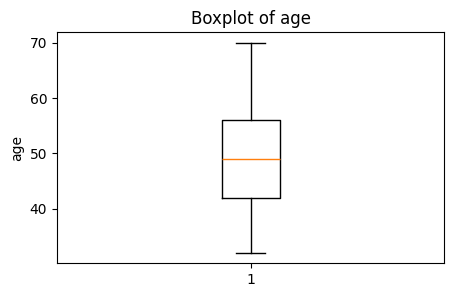

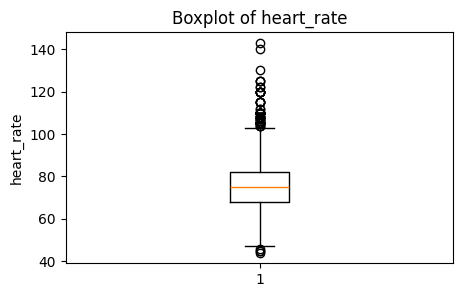

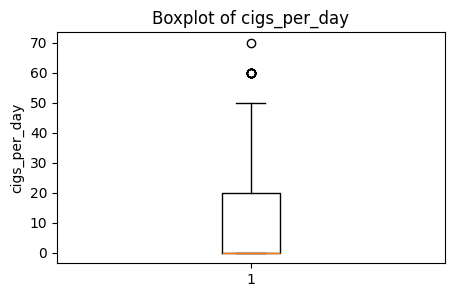

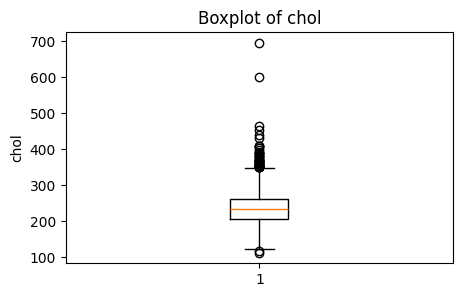

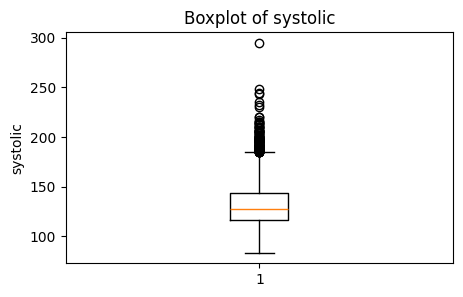

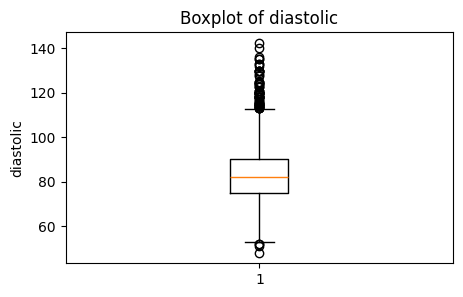

In [7]:
num_cols = ['age', 'heart_rate', 'cigs_per_day', 'chol', 'systolic', 'diastolic']

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

5. Distribusi fitur

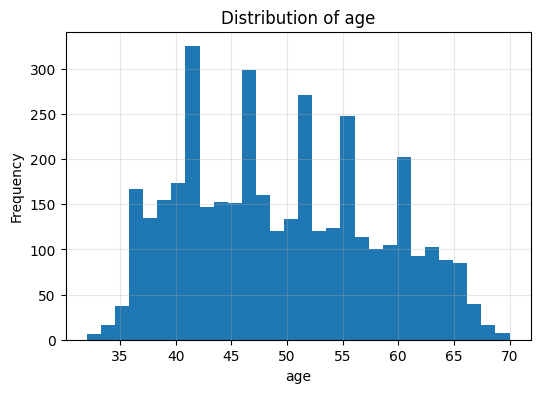

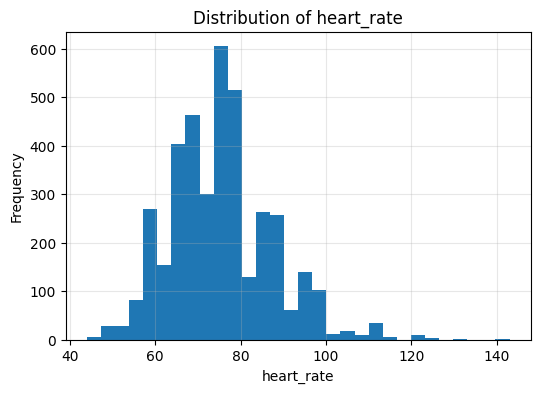

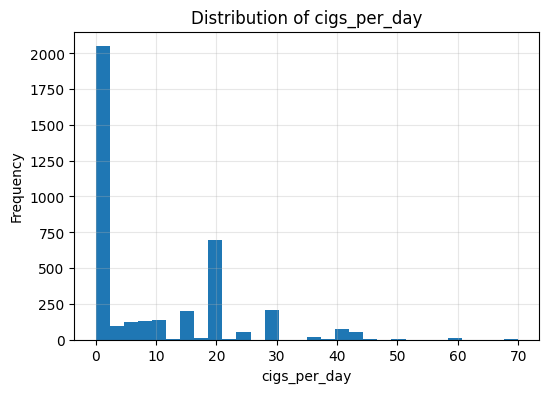

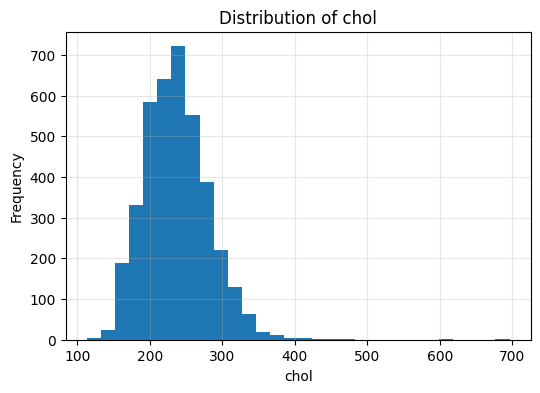

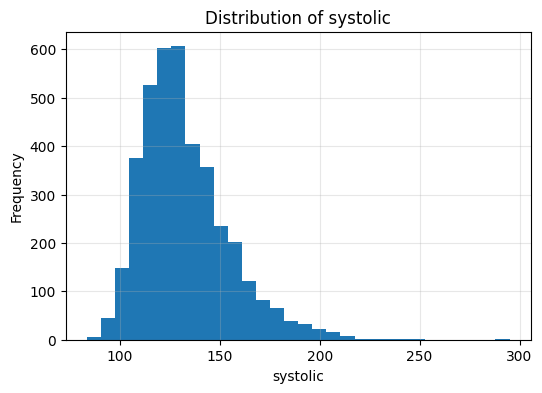

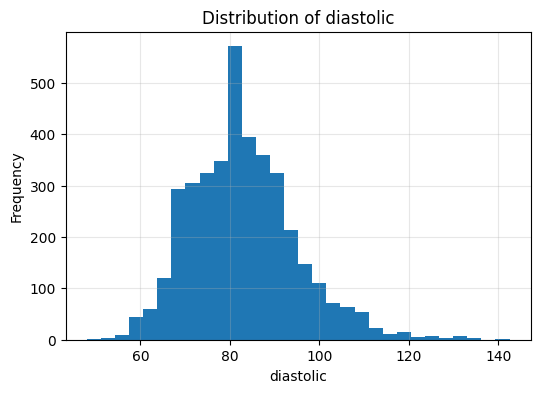

In [8]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()


6. Heatmap korelasi fitur

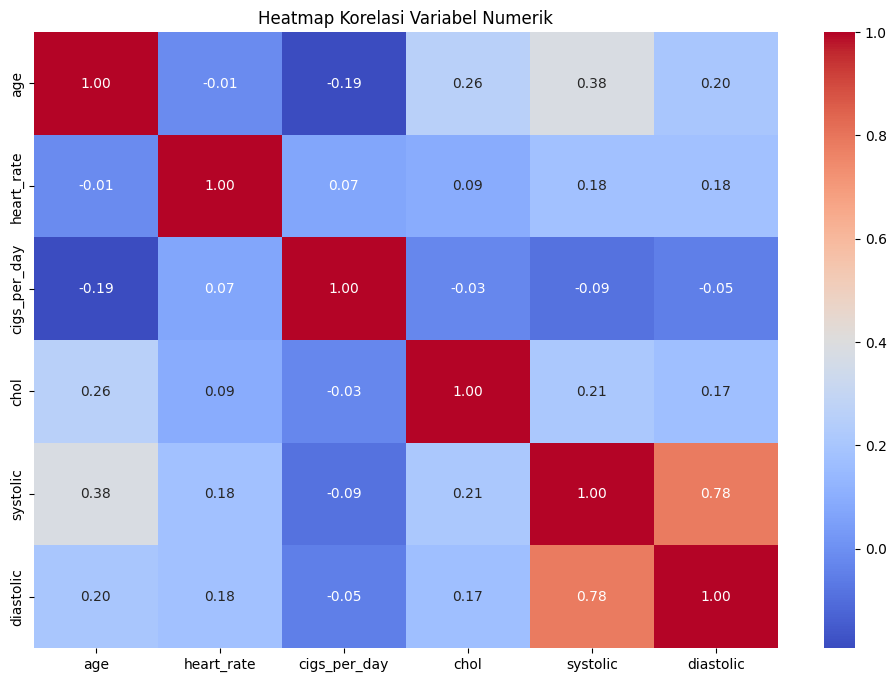

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Variabel Numerik")
plt.show()

Informasi yang dapat diambil dari heatmap korelasi fitur tersebut adalah sebagai berikut:  
age - Informasi penting, tidak redundan.  
sex - Biasanya signifikan dalam model risk factor. (perlu di-encode dulu)  
heart_rate - Korelasi rendah dan memberi informasi unik.  
chol - Penting untuk risiko kesehatan.  
cigs_per_day - Kunci untuk model yang berhubungan dengan smoking.  
systolic - Lebih informatif dibanding diastolic (dalam banyak studi kesehatan).  
diastolic - Bisa dipertahankan atau dibuang jika terlalu redundant.

7. Relationship antar fitur

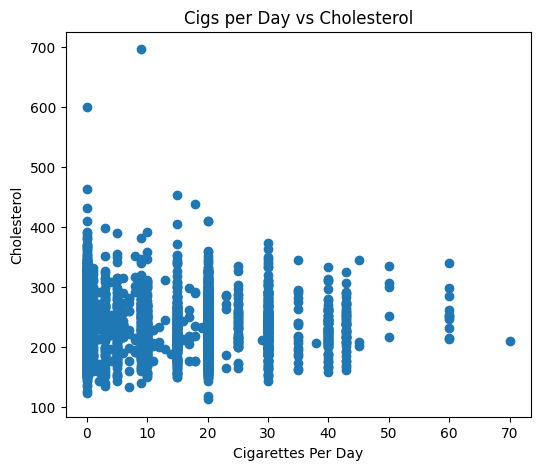

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(df['cigs_per_day'], df['chol'])
plt.xlabel("Cigarettes Per Day")
plt.ylabel("Cholesterol")
plt.title("Cigs per Day vs Cholesterol")
plt.show()

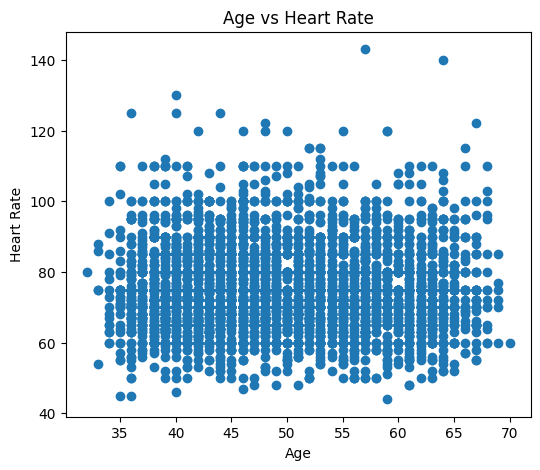

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(df['age'], df['heart_rate'])
plt.xlabel("Age")
plt.ylabel("Heart Rate")
plt.title("Age vs Heart Rate")
plt.show()